# FINAL — Normalizing Flow / RealNVP 

Questo notebook implementa il **Normalizing Flow finale** usando i dataset aggregate creati dal preprocessing `FINAL`.

Input previsto:

```text
FINAL/processed/repr1_aggregate.npz
```

Il modello è un **RealNVP stabile** addestrato solo su QCD/background,
impara una trasformazione invertibile che porta i dati reali, in questo caso jet QCD, verso una distribuzione semplice, di solito una gaussiana standard.

L’idea è che i jet QCD, essendo usati per il training, dovrebbero avere alta probabilità secondo il modello. Eventi più strani, come possibili Emerging Jets, dovrebbero invece risultare meno probabili e quindi avere uno score di anomalia più alto.

La versione “stabile” serve soprattutto a evitare problemi numerici durante il training. Per questo si usano accorgimenti come clipping o limitazione dei fattori di scala, normalizzazione delle feature, weight decay e controlli su valori `NaN` o infiniti. In questo modo il flow resta invertibile e la likelihood non esplode numericamente.

In sintesi, il RealNVP stabile viene usato per stimare quanto un evento è compatibile con la distribuzione QCD appresa: più la likelihood è bassa, più l’evento è considerato anomalo.
Schema:

```text
bkg_train  -> training QCD
bkg_eval   -> validation QCD + test QCD interno
sig        -> signal EJ
```


Score di anomalia:

```text
score = NLL = -log p(x)
```

dove `x` è il vettore aggregate jet+track.



## 1. Import, seed e device

In [1]:
from pathlib import Path
import json
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path e caricamento dataset aggregate

In [2]:
# Funziona sia se il notebook è lanciato da FINAL/notebooks,
# sia se è lanciato dalla root del progetto.

CANDIDATE_BASES = [
    Path(".."),
    Path("."),
    Path("FINAL"),
]

PROCESSED_PATH = None

for base in CANDIDATE_BASES:
    candidate = base / "processed" / "repr1_aggregate.npz"
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        "Non trovo repr1_aggregate.npz. "
        "Controlla che esista in FINAL/processed/repr1_aggregate.npz "
        "oppure modifica PROCESSED_PATH manualmente."
    )

OUTPUT_DIR = PROJECT_BASE / "outputs" / "normalizing_flow"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_PATH:", PROCESSED_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)
print("\nKeys in repr1_aggregate.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr1_aggregate.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\normalizing_flow

Keys in repr1_aggregate.npz:
  bkg_train                           shape=(100000, 96) dtype=float32
  bkg_eval                            shape=(100000, 96) dtype=float32
  sig                                 shape=(61966, 96) dtype=float32
  feature_names                       shape=(96,) dtype=object
  norm_mean                           shape=(1, 96) dtype=float32
  norm_std                            shape=(1, 96) dtype=float32


## 3. Loader robusto delle chiavi

In [3]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )
    return None


train_key = first_existing_key(
    data,
    [
        "X_agg_bkg_train",
        "bkg_train",
        "X_bkg_train",
        "X_train_background",
        "X_agg_train_background",
        "train_background",
        "X_train",
    ],
)

eval_key = first_existing_key(
    data,
    [
        "X_agg_bkg_eval",
        "bkg_eval",
        "X_bkg_eval",
        "X_eval_background",
        "X_agg_eval_background",
        "eval_background",
        "X_eval",
        "X_val",
    ],
)

test_bkg_key = first_existing_key(
    data,
    [
        "X_agg_bkg_test",
        "bkg_test",
        "X_bkg_test",
        "X_test_background",
        "X_agg_test_background",
        "test_background",
        "X_test_bkg",
    ],
    required=False,
)

sig_key = first_existing_key(
    data,
    [
        "X_agg_sig",
        "sig",
        "X_sig",
        "X_signal",
        "X_test_signal",
        "X_agg_test_signal",
        "test_signal",
    ],
)

feature_key = first_existing_key(
    data,
    [
        "aggregate_feature_names",
        "agg_feature_names",
        "feature_names",
        "X_agg_feature_names",
    ],
    required=False,
)

X_train_raw = np.asarray(data[train_key], dtype=np.float32)
X_eval_raw = np.asarray(data[eval_key], dtype=np.float32)
X_sig_raw = np.asarray(data[sig_key], dtype=np.float32)

if test_bkg_key is not None:
    X_bkg_test_raw = np.asarray(data[test_bkg_key], dtype=np.float32)
    X_val_raw = X_eval_raw
    print("Uso test background separato:", test_bkg_key)
else:
    X_val_raw, X_bkg_test_raw = train_test_split(
        X_eval_raw,
        test_size=0.5,
        random_state=SEED,
        shuffle=True,
    )
    #print("Nessun test background separato trovato: splitto bkg_eval in val/test 50/50.")

if feature_key is not None:
    aggregate_feature_names = [str(x) for x in data[feature_key].tolist()]
else:
    aggregate_feature_names = [f"f{i}" for i in range(X_train_raw.shape[1])]

print("\nSelected keys:")
print("train:", train_key, X_train_raw.shape)
print("eval:", eval_key, X_eval_raw.shape)
print("val:", X_val_raw.shape)
print("bkg_test:", test_bkg_key, X_bkg_test_raw.shape)
print("signal:", sig_key, X_sig_raw.shape)
print("n features:", len(aggregate_feature_names))


Selected keys:
train: bkg_train (100000, 96)
eval: bkg_eval (100000, 96)
val: (50000, 96)
bkg_test: None (50000, 96)
signal: sig (61966, 96)
n features: 96


## 4. Anti-leakage check

In [4]:
FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]

bad_features = []

for name in aggregate_feature_names:
    for bad in FORBIDDEN_SUBSTRINGS:
        if bad.lower() in name.lower():
            bad_features.append(name)

if bad_features:
    print("ERRORE: trovate feature potenzialmente leaky negli input aggregate:")
    for f in bad_features:
        print("  ", f)
    raise RuntimeError("Leakage check failed. Rimuovi queste feature dal preprocessing.")
else:
    print("Leakage check OK: nessuna feature vietata trovata negli input aggregate.")

Leakage check OK: nessuna feature vietata trovata negli input aggregate.


## 5. Pulizia, robust scaling e clipping

In [5]:
def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)
    if not finite.all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:", np.sum(~finite))
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X


X_train_raw = finite_array(X_train_raw, "X_train_raw")
X_val_raw = finite_array(X_val_raw, "X_val_raw")
X_bkg_test_raw = finite_array(X_bkg_test_raw, "X_bkg_test_raw")
X_sig_raw = finite_array(X_sig_raw, "X_sig_raw")


class RobustClipScaler:
    def __init__(self, clip_value=8.0, eps=1e-6):
        self.clip_value = clip_value
        self.eps = eps
        self.center = None
        self.scale = None

    def fit(self, X):
        self.center = np.median(X, axis=0, keepdims=True)
        q25 = np.percentile(X, 25, axis=0, keepdims=True)
        q75 = np.percentile(X, 75, axis=0, keepdims=True)
        self.scale = np.maximum(q75 - q25, self.eps)
        return self

    def transform(self, X):
        Xn = (X - self.center) / self.scale
        Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0)
        Xn = np.clip(Xn, -self.clip_value, self.clip_value)
        return Xn.astype(np.float32)

    def state_dict(self):
        return {
            "clip_value": float(self.clip_value),
            "eps": float(self.eps),
            "center": self.center.reshape(-1).tolist(),
            "scale": self.scale.reshape(-1).tolist(),
        }


CLIP_VALUE = 8.0

scaler = RobustClipScaler(clip_value=CLIP_VALUE)
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_bkg_test = scaler.transform(X_bkg_test_raw)
X_sig = scaler.transform(X_sig_raw)

print("After robust scaling + clipping:")
for name, X in [
    ("train", X_train),
    ("val", X_val),
    ("bkg_test", X_bkg_test),
    ("signal", X_sig),
]:
    print(
        f"{name:10s} shape={X.shape} "
        f"mean={X.mean():.4f} std={X.std():.4f} "
        f"clip_frac={np.mean((X <= -CLIP_VALUE) | (X >= CLIP_VALUE)):.5f}"
    )

input_dim = X_train.shape[1]
print("input_dim:", input_dim)

with open(OUTPUT_DIR / "aggregate_flow_scaler.json", "w") as f:
    json.dump(scaler.state_dict(), f, indent=2)

print("Saved scaler:", OUTPUT_DIR / "aggregate_flow_scaler.json")

After robust scaling + clipping:
train      shape=(100000, 96) mean=0.0088 std=1.1453 clip_frac=0.00944
val        shape=(50000, 96) mean=0.0077 std=1.1425 clip_frac=0.00941
bkg_test   shape=(50000, 96) mean=0.0059 std=1.1436 clip_frac=0.00944
signal     shape=(61966, 96) mean=-0.0578 std=1.6772 clip_frac=0.02470
input_dim: 96
Saved scaler: ..\outputs\normalizing_flow\aggregate_flow_scaler.json


## 6. Dataset e DataLoader

In [6]:
class AggregateDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


BATCH_SIZE = 1024

train_loader = DataLoader(
    AggregateDataset(X_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    AggregateDataset(X_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 98
Val batches: 49


## 7. Modello RealNVP stabile

In [7]:
class CouplingNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, output_dim),
        )

        # Inizializzazione identità: il flow parte quasi come z=x
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


class AffineCouplingLayer(nn.Module):
    def __init__(self, dim, mask, hidden_dim=256, scale_clip=2.0):
        super().__init__()

        self.dim = dim
        # La maschera decide quali feature restano fisse e quali vengono trasformate
        self.register_buffer("mask", mask.bool())
        self.scale_clip = scale_clip

        self.active_idx = torch.where(self.mask)[0]
        self.passive_idx = torch.where(~self.mask)[0]

        input_dim = int(self.mask.sum().item())
        output_dim = dim - input_dim
# Due reti separate: una predice la scala, l'altra la traslazione
        self.s_net = CouplingNetwork(input_dim, output_dim, hidden_dim=hidden_dim)
        self.t_net = CouplingNetwork(input_dim, output_dim, hidden_dim=hidden_dim)

    def forward(self, x):
        x_active = x[:, self.active_idx]
        x_passive = x[:, self.passive_idx]

        s = self.s_net(x_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)

        t = self.t_net(x_active)

        z = x.clone()
        z_passive = x_passive * torch.exp(s) + t
        z[:, self.passive_idx] = z_passive

        log_det = s.sum(dim=1)

        return z, log_det

    def inverse(self, z):
        # Operazione inversa della trasformazione precedente
        z_active = z[:, self.active_idx]
        z_passive = z[:, self.passive_idx]

        s = self.s_net(z_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)

        t = self.t_net(z_active)

        x = z.clone()
        x_passive = (z_passive - t) * torch.exp(-s)
        x[:, self.passive_idx] = x_passive

        log_det = -s.sum(dim=1)

        return x, log_det


class PermutationLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
# Permuto le feature tra un coupling layer e il successivo,così nel tempo tutte le variabili possono influenzarsi tra loro
        perm = torch.randperm(dim)
        inv_perm = torch.argsort(perm)

        self.register_buffer("perm", perm)
        self.register_buffer("inv_perm", inv_perm)

    def forward(self, x):
        return x[:, self.perm], torch.zeros(x.shape[0], device=x.device)

    def inverse(self, z):
        return z[:, self.inv_perm], torch.zeros(z.shape[0], device=z.device)


class RealNVPStable(nn.Module):
    def __init__(self, dim, n_layers=8, hidden_dim=256, scale_clip=2.0):
        super().__init__()

        self.dim = dim
        self.n_layers = n_layers

        layers = []

        for i in range(n_layers):
            mask = torch.zeros(dim, dtype=torch.bool)
# Alterno le feature trasformate tra layer pari e dispari
            if i % 2 == 0:
                mask[::2] = True
            else:
                mask[1::2] = True

            layers.append(
                AffineCouplingLayer(
                    dim=dim,
                    mask=mask,
                    hidden_dim=hidden_dim,
                    scale_clip=scale_clip,
                )
            )
 # Dopo ogni coupling layer mescolo le feature
            layers.append(PermutationLayer(dim))

        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        # Trasformo i dati x nello spazio latente z
        z = x
        total_log_det = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            total_log_det = total_log_det + log_det

        return z, total_log_det

    def inverse(self, z):
        x = z
        total_log_det = torch.zeros(z.shape[0], device=z.device)

        for layer in reversed(self.layers):
            x, log_det = layer.inverse(x)
            total_log_det = total_log_det + log_det

        return x, total_log_det

    def log_prob(self, x):
          #Calcolo la log-likelihood dei dati, prima porto x nello spazio latente z, poi valuto z sotto una gaussiana standard
        z, log_det = self.forward(x)

        log_base = -0.5 * (z ** 2).sum(dim=1)
        log_base = log_base - 0.5 * self.dim * math.log(2 * math.pi)

        return log_base + log_det

    def negative_log_likelihood(self, x):
        # Loss da minimizzare: vogliamo massimizzare la likelihood, quindi minimizziamo il suo opposto
        return -self.log_prob(x)

## 7.1 Quick hyperparameter tuning RealNVP

Questa sezione fa un tuning leggero degli iperparametri principali del Normalizing Flow usando solo **QCD train/validation**.  
Il segnale EJ non viene mai usato per scegliere la configurazione migliore.


In [8]:
# ============================================================
# Quick hyperparameter tuning — Normalizing Flow / RealNVP
# ============================================================
# Criterio:
# - uso solo QCD train/validation;
# - non uso mai il segnale EJ;
# - alleno pochi epoch su un subset;
# - scelgo la configurazione con validation NLL QCD più bassa;
# - penalizzo leggermente overfitting train/validation.
#
# Iperparametri testati:
# - n_flow_layers: profondità del flow;
# - hidden_dim: larghezza delle reti s/t nei coupling layer;
# - scale_clip: stabilizzazione delle scale;
# - learning rate;
# - weight decay;
# - batch size.
# ============================================================

import gc

RUN_FLOW_HPARAM_TUNING = True

TUNE_MAX_TRAIN = 12_000
TUNE_MAX_VAL = 8_000
TUNE_EPOCHS = 20
TUNE_PATIENCE = 5


CANDIDATE_CONFIGS = [
    {
        "n_flow_layers": 4,
        "hidden_dim": 128,
        "scale_clip": 1.5,
        "lr": 5e-5,
        "weight_decay": 0.0,
        "batch_size": 1024,
    },
    {
        "n_flow_layers": 6,
        "hidden_dim": 128,
        "scale_clip": 2.0,
        "lr": 4e-5,
        "weight_decay": 1e-6,
        "batch_size": 1024,
    },
    {
        "n_flow_layers": 8,
        "hidden_dim": 256,
        "scale_clip": 2.0,
        "lr": 3e-5,
        "weight_decay": 1e-6,
        "batch_size": 1024,
    },
    {
        "n_flow_layers": 10,
        "hidden_dim": 256,
        "scale_clip": 2.0,
        "lr": 3e-5,
        "weight_decay": 1e-5,
        "batch_size": 1024,
    },
    {
        "n_flow_layers": 12,
        "hidden_dim": 256,
        "scale_clip": 2.5,
        "lr": 2e-5,
        "weight_decay": 1e-5,
        "batch_size": 768,
    },
    {
        "n_flow_layers": 12,
        "hidden_dim": 512,
        "scale_clip": 2.0,
        "lr": 2e-5,
        "weight_decay": 1e-5,
        "batch_size": 512,
    },
    {
        "n_flow_layers": 16,
        "hidden_dim": 256,
        "scale_clip": 2.0,
        "lr": 2e-5,
        "weight_decay": 1e-5,
        "batch_size": 768,
    },
    {
        "n_flow_layers": 16,
        "hidden_dim": 512,
        "scale_clip": 2.5,
        "lr": 1.5e-5,
        "weight_decay": 1e-4,
        "batch_size": 512,
    },
]


def _subsample(X, max_n, seed):
    if len(X) <= max_n:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_n, replace=False)
    return X[idx]


X_tune_train = _subsample(X_train, TUNE_MAX_TRAIN, SEED)
X_tune_val = _subsample(X_val, TUNE_MAX_VAL, SEED + 1)

print("Tuning train:", X_tune_train.shape)
print("Tuning val:", X_tune_val.shape)


def make_tune_loader(X, batch_size, shuffle=False):
    return DataLoader(
        AggregateDataset(X),
        batch_size=int(batch_size),
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


@torch.no_grad()
def tune_evaluate_nll(model, loader):
    model.eval()

    total_loss = 0.0
    total_items = 0

    for X_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        nll = model.negative_log_likelihood(X_batch)
        loss = nll.mean()
        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    return total_loss / max(total_items, 1)


def tune_one_flow_config(cfg, config_id):
    print("\n" + "=" * 90)
    print(f"REALNVP CONFIG {config_id}/{len(CANDIDATE_CONFIGS)}")
    print(cfg)

    train_l = make_tune_loader(
        X_tune_train,
        batch_size=int(cfg["batch_size"]),
        shuffle=True,
    )

    val_l = make_tune_loader(
        X_tune_val,
        batch_size=int(cfg["batch_size"]),
        shuffle=False,
    )

    model_tune = RealNVPStable(
        dim=input_dim,
        n_layers=int(cfg["n_flow_layers"]),
        hidden_dim=int(cfg["hidden_dim"]),
        scale_clip=float(cfg["scale_clip"]),
    ).to(device)

    n_params = sum(p.numel() for p in model_tune.parameters() if p.requires_grad)

    optimizer_tune = torch.optim.AdamW(
        model_tune.parameters(),
        lr=float(cfg["lr"]),
        weight_decay=float(cfg["weight_decay"]),
    )

    scheduler_tune = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_tune,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_val = np.inf
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, TUNE_EPOCHS + 1):
        model_tune.train()
        train_losses = []

        for X_batch in train_l:
            X_batch = X_batch.to(device, non_blocking=True)

            optimizer_tune.zero_grad()

            nll = model_tune.negative_log_likelihood(X_batch)
            loss = nll.mean()

            if not torch.isfinite(loss):
                raise RuntimeError("RealNVP tuning loss non finita")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tune.parameters(), max_norm=5.0)
            optimizer_tune.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = tune_evaluate_nll(model_tune, val_l)
        scheduler_tune.step(val_loss)

        print(
            f"epoch {epoch:02d}/{TUNE_EPOCHS} | "
            f"train NLL={train_loss:.6f} | "
            f"val NLL={val_loss:.6f} | "
            f"best={best_val:.6f}"
        )

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model_tune.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= TUNE_PATIENCE:
            print("early stopping tuning")
            break

    if best_state is not None:
        model_tune.load_state_dict(best_state)

    train_loss_final = tune_evaluate_nll(model_tune, train_l)
    val_loss_final = tune_evaluate_nll(model_tune, val_l)

    gap = max(0.0, val_loss_final - train_loss_final)

    # Score di selezione:
    # - validation NLL più bassa è meglio;
    # - penalizzo leggermente gap train/val.
    selection_score = best_val + 0.30 * gap

    result = {
        "config_id": config_id,
        **cfg,
        "n_params": int(n_params),
        "best_epoch": int(best_epoch),
        "train_nll": float(train_loss_final),
        "val_nll": float(val_loss_final),
        "generalization_gap": float(gap),
        "selection_score": float(selection_score),
    }

    del model_tune
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


if RUN_FLOW_HPARAM_TUNING:
    flow_tuning_rows = []

    for i, cfg in enumerate(CANDIDATE_CONFIGS, start=1):
        try:
            flow_tuning_rows.append(tune_one_flow_config(cfg, i))
        except RuntimeError as e:
            print(f"[SKIP CONFIG {i}] RuntimeError:", e)
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    flow_tuning_results_df = pd.DataFrame(flow_tuning_rows)

    flow_tuning_results_df = flow_tuning_results_df.sort_values(
        "selection_score",
        ascending=True,
    ).reset_index(drop=True)

    display(flow_tuning_results_df)

    flow_tuning_results_df.to_csv(
        OUTPUT_DIR / "realnvp_hparam_tuning.csv",
        index=False,
    )

    print("Saved:", OUTPUT_DIR / "realnvp_hparam_tuning.csv")

    BEST_FLOW_CONFIG = flow_tuning_results_df.iloc[0].to_dict()

else:
    BEST_FLOW_CONFIG = {
        "n_flow_layers": 8,
        "hidden_dim": 256,
        "scale_clip": 2.0,
        "lr": 3e-5,
        "weight_decay": 1e-6,
        "batch_size": 1024,
    }

print("\n" + "=" * 90)
print("BEST REALNVP CONFIG")
print(BEST_FLOW_CONFIG)

# Imposto le variabili globali che verranno usate dal training finale.
N_FLOW_LAYERS = int(BEST_FLOW_CONFIG["n_flow_layers"])
HIDDEN_DIM = int(BEST_FLOW_CONFIG["hidden_dim"])
SCALE_CLIP = float(BEST_FLOW_CONFIG["scale_clip"])
LR = float(BEST_FLOW_CONFIG["lr"])
WEIGHT_DECAY = float(BEST_FLOW_CONFIG["weight_decay"])
BATCH_SIZE = int(BEST_FLOW_CONFIG["batch_size"])

# Training finale: più lungo del tuning.
N_EPOCHS = 100
PATIENCE = 15

print("\nIperparametri finali impostati:")
print("N_FLOW_LAYERS =", N_FLOW_LAYERS)
print("HIDDEN_DIM    =", HIDDEN_DIM)
print("SCALE_CLIP    =", SCALE_CLIP)
print("LR            =", LR)
print("WEIGHT_DECAY  =", WEIGHT_DECAY)
print("BATCH_SIZE    =", BATCH_SIZE)
print("N_EPOCHS      =", N_EPOCHS)
print("PATIENCE      =", PATIENCE)

Tuning train: (12000, 96)
Tuning val: (8000, 96)

REALNVP CONFIG 1/8
{'n_flow_layers': 4, 'hidden_dim': 128, 'scale_clip': 1.5, 'lr': 5e-05, 'weight_decay': 0.0, 'batch_size': 1024}
epoch 01/20 | train NLL=149.985385 | val NLL=149.135249 | best=inf
epoch 02/20 | train NLL=147.840830 | val NLL=146.866434 | best=149.135249
epoch 03/20 | train NLL=145.413513 | val NLL=144.284363 | best=146.866434
epoch 04/20 | train NLL=142.726363 | val NLL=141.401043 | best=144.284363
epoch 05/20 | train NLL=139.802887 | val NLL=138.281742 | best=141.401043
epoch 06/20 | train NLL=136.582031 | val NLL=135.008874 | best=138.281742
epoch 07/20 | train NLL=133.244612 | val NLL=131.685028 | best=135.008874
epoch 08/20 | train NLL=129.983173 | val NLL=128.378870 | best=131.685028
epoch 09/20 | train NLL=126.711270 | val NLL=125.164317 | best=128.378870
epoch 10/20 | train NLL=123.507596 | val NLL=122.064664 | best=125.164317
epoch 11/20 | train NLL=120.418348 | val NLL=119.090016 | best=122.064664
epoch 12/20

,config_id,n_flow_layers,hidden_dim,scale_clip,lr,weight_decay,batch_size,n_params,best_epoch,train_nll,val_nll,generalization_gap,selection_score
0,3,8,256,2.0,0.000030,0.000001,1024,1450752,19,626.049027,87.917349,0.000000,87.917349
1,5,12,256,2.5,0.000020,0.000010,768,2176128,13,92.201157,91.784250,0.000000,91.784250
2,7,16,256,2.0,0.000020,0.000010,768,2901504,10,135.670742,94.661759,0.000000,94.661759
3,4,10,256,2.0,0.000030,0.000010,1024,1813440,14,91.495349,94.511538,3.016189,95.416395
4,2,6,128,2.0,0.000040,0.000001,1024,347712,20,96.865703,95.905216,0.000000,95.905216
5,6,12,512,2.0,0.000020,0.000010,512,7496832,4,102.414669,98.964345,0.000000,98.964345
6,1,4,128,1.5,0.000050,0.000000,1024,231808,20,98.776752,99.295849,0.519097,99.451578
7,8,16,512,2.5,0.000015,0.000100,512,9995776,4,3426.897874,102.291461,0.000000,102.291461


Saved: ..\outputs\normalizing_flow\realnvp_hparam_tuning.csv

BEST REALNVP CONFIG
{'config_id': 3.0, 'n_flow_layers': 8.0, 'hidden_dim': 256.0, 'scale_clip': 2.0, 'lr': 3e-05, 'weight_decay': 1e-06, 'batch_size': 1024.0, 'n_params': 1450752.0, 'best_epoch': 19.0, 'train_nll': 626.0490273844401, 'val_nll': 87.9173491821289, 'generalization_gap': 0.0, 'selection_score': 87.9173491821289}

Iperparametri finali impostati:
N_FLOW_LAYERS = 8
HIDDEN_DIM    = 256
SCALE_CLIP    = 2.0
LR            = 3e-05
WEIGHT_DECAY  = 1e-06
BATCH_SIZE    = 1024
N_EPOCHS      = 100
PATIENCE      = 15


## 7.2 Plot tuning RealNVP in stile gomito

Questi plot mostrano l’effetto dei principali iperparametri.  
Il criterio è sempre: **più basso è meglio**.


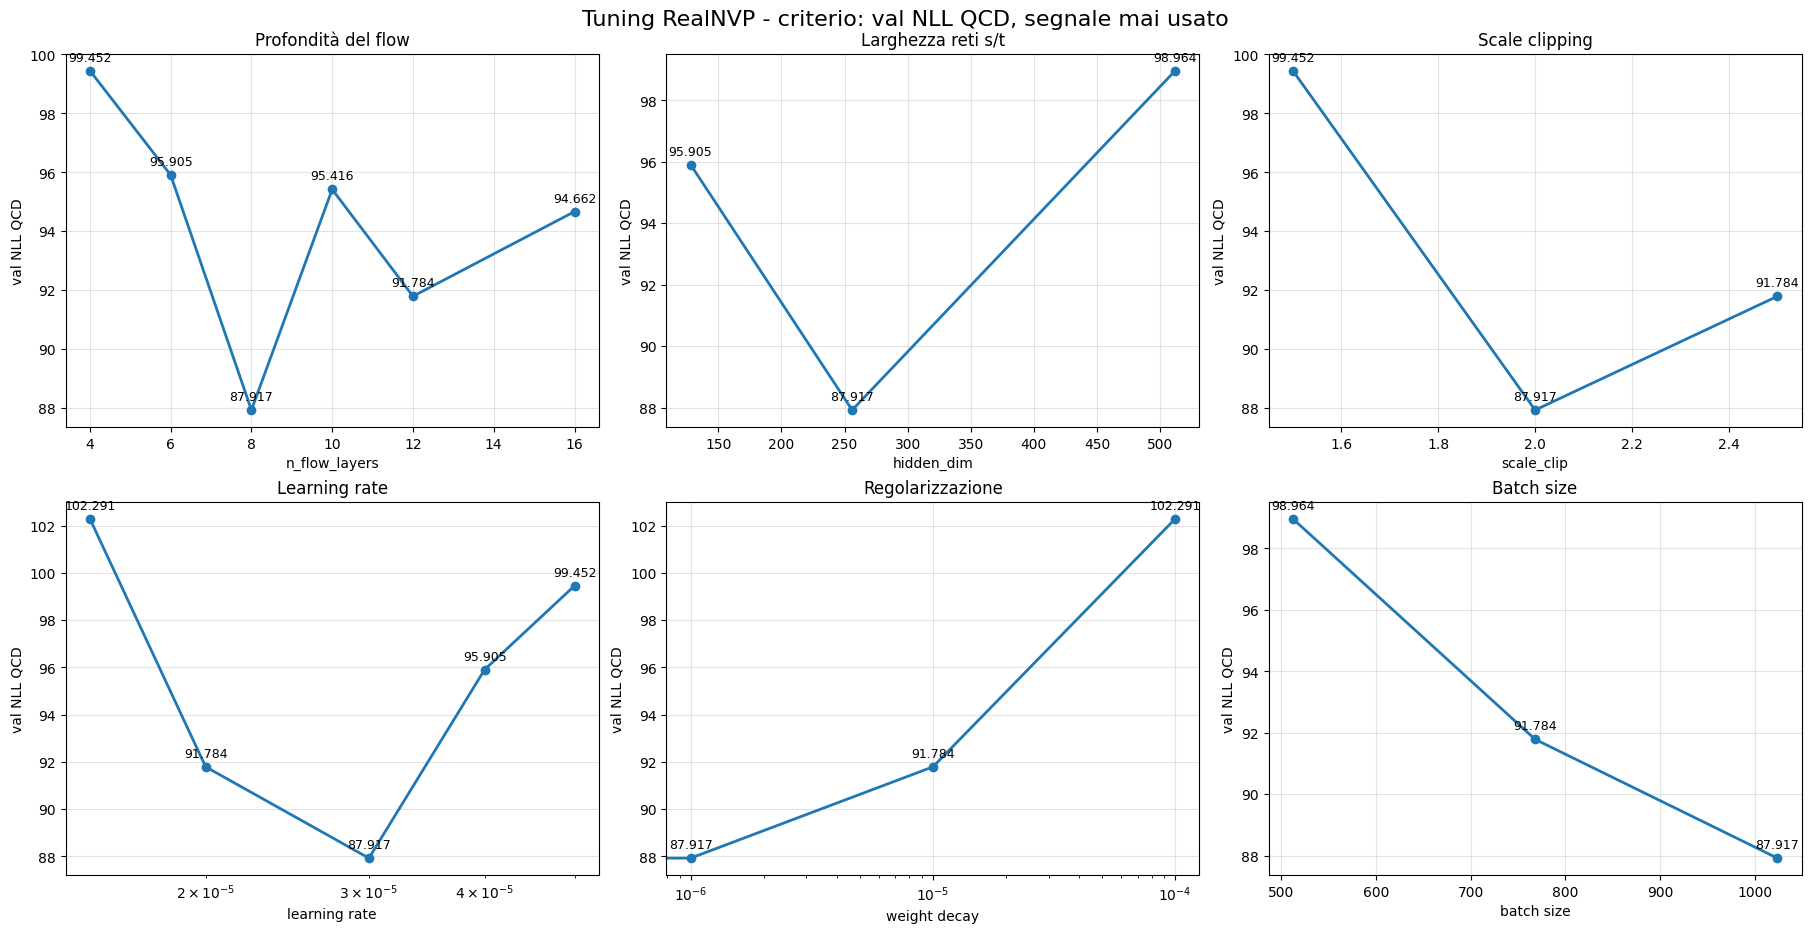

Salvato: ..\outputs\normalizing_flow\plots\realnvp_hparam_elbow_plots.png


,config_id,n_flow_layers,hidden_dim,scale_clip,lr,weight_decay,batch_size,n_params,best_epoch,train_nll,val_nll,generalization_gap,selection_score
0,3,8,256,2.0,0.000030,0.000001,1024,1450752,19,626.049027,87.917349,0.000000,87.917349
1,5,12,256,2.5,0.000020,0.000010,768,2176128,13,92.201157,91.784250,0.000000,91.784250
2,7,16,256,2.0,0.000020,0.000010,768,2901504,10,135.670742,94.661759,0.000000,94.661759
3,4,10,256,2.0,0.000030,0.000010,1024,1813440,14,91.495349,94.511538,3.016189,95.416395
4,2,6,128,2.0,0.000040,0.000001,1024,347712,20,96.865703,95.905216,0.000000,95.905216
5,6,12,512,2.0,0.000020,0.000010,512,7496832,4,102.414669,98.964345,0.000000,98.964345
6,1,4,128,1.5,0.000050,0.000000,1024,231808,20,98.776752,99.295849,0.519097,99.451578
7,8,16,512,2.5,0.000015,0.000100,512,9995776,4,3426.897874,102.291461,0.000000,102.291461


In [9]:
# ============================================================
# Plot tuning RealNVP in stile "gomito"
# ============================================================

try:
    df_flow_tune = flow_tuning_results_df.copy()
except NameError:
    df_flow_tune = pd.read_csv(OUTPUT_DIR / "realnvp_hparam_tuning.csv")

Y_COL = "selection_score"
Y_LABEL = "val NLL QCD"


def best_by_param(data, param):
    return (
        data
        .groupby(param, as_index=False)[Y_COL]
        .min()
        .sort_values(param)
        .reset_index(drop=True)
    )


def plot_line_with_labels(ax, x, y, xlabel, title, logx=False):
    ax.plot(x, y, marker="o", linewidth=2)

    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.3f}",
            xy=(xi, yi),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(Y_LABEL)
    ax.set_title(title)
    ax.grid(True, alpha=0.35)

    if logx:
        ax.set_xscale("log")


fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    constrained_layout=True,
)

axes = axes.flatten()

fig.suptitle(
    "Tuning RealNVP - criterio: val NLL QCD, segnale mai usato",
    fontsize=16,
    y=1.02,
)

for ax, param, xlabel, title, logx in [
    (axes[0], "n_flow_layers", "n_flow_layers", "Profondità del flow", False),
    (axes[1], "hidden_dim", "hidden_dim", "Larghezza reti s/t", False),
    (axes[2], "scale_clip", "scale_clip", "Scale clipping", False),
    (axes[3], "lr", "learning rate", "Learning rate", True),
    (axes[4], "weight_decay", "weight decay", "Regolarizzazione", True),
    (axes[5], "batch_size", "batch size", "Batch size", False),
]:
    g = best_by_param(df_flow_tune, param)
    plot_line_with_labels(
        ax,
        g[param],
        g[Y_COL],
        xlabel,
        title,
        logx=logx,
    )

out_path = PLOTS_DIR / "realnvp_hparam_elbow_plots.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Salvato:", out_path)
display(df_flow_tune.sort_values("selection_score").reset_index(drop=True))

## 8. Training

In [10]:
# ============================================================
# Creazione modello finale usando la configurazione scelta dal tuning
# ============================================================


if "BEST_FLOW_CONFIG" in globals():
    N_FLOW_LAYERS = int(BEST_FLOW_CONFIG["n_flow_layers"])
    HIDDEN_DIM = int(BEST_FLOW_CONFIG["hidden_dim"])
    SCALE_CLIP = float(BEST_FLOW_CONFIG["scale_clip"])
    LR = float(BEST_FLOW_CONFIG["lr"])
    WEIGHT_DECAY = float(BEST_FLOW_CONFIG["weight_decay"])
    BATCH_SIZE = int(BEST_FLOW_CONFIG["batch_size"])

    N_EPOCHS = 100
    PATIENCE = 15

    print("Uso configurazione scelta dal tuning.")
else:
    N_FLOW_LAYERS = 8
    HIDDEN_DIM = 256
    SCALE_CLIP = 2.0
    LR = 3e-5
    WEIGHT_DECAY = 1e-6

    BATCH_SIZE = 1024
    N_EPOCHS = 80
    PATIENCE = 12

    print("BEST_FLOW_CONFIG non trovata: uso configurazione standard.")

# Ricreo i DataLoader finali con il batch size scelto.
train_loader = DataLoader(
    AggregateDataset(X_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    AggregateDataset(X_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

flow = RealNVPStable(
    dim=input_dim,
    n_layers=N_FLOW_LAYERS,
    hidden_dim=HIDDEN_DIM,
    scale_clip=SCALE_CLIP,
).to(device)

optimizer = torch.optim.AdamW(
    flow.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

print(flow)
print("Parameters:", sum(p.numel() for p in flow.parameters() if p.requires_grad))
print()
print("Final RealNVP config:")
print("N_FLOW_LAYERS =", N_FLOW_LAYERS)
print("HIDDEN_DIM    =", HIDDEN_DIM)
print("SCALE_CLIP    =", SCALE_CLIP)
print("LR            =", LR)
print("WEIGHT_DECAY  =", WEIGHT_DECAY)
print("BATCH_SIZE    =", BATCH_SIZE)
print("N_EPOCHS      =", N_EPOCHS)
print("PATIENCE      =", PATIENCE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Uso configurazione scelta dal tuning.
RealNVPStable(
  (layers): ModuleList(
    (0): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=48, out_features=256, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): LeakyReLU(negative_slope=0.1)
          (4): Linear(in_features=256, out_features=48, bias=True)
        )
      )
      (t_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=48, out_features=256, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): LeakyReLU(negative_slope=0.1)
          (4): Linear(in_features=256, out_features=48, bias=True)
        )
      )
    )
    (1): PermutationLayer()
    (2): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_feature

In [11]:
def evaluate_nll(model, loader):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            nll = model.negative_log_likelihood(X_batch)
            loss = nll.mean()

            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / max(total_items, 1)


train_history = []
val_history = []
lr_history = []

best_val = np.inf
best_epoch = -1
best_state = None
epochs_no_improve = 0

for epoch in range(N_EPOCHS):
    flow.train()

    total_loss = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        nll = flow.negative_log_likelihood(X_batch)
        loss = nll.mean()

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita. Prova a ridurre LR, scale_clip o clip_value.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    train_nll = total_loss / max(total_items, 1)
    val_nll = evaluate_nll(flow, val_loader)

    scheduler.step(val_nll)
    current_lr = optimizer.param_groups[0]["lr"]

    train_history.append(train_nll)
    val_history.append(val_nll)
    lr_history.append(current_lr)

    improved = val_nll < best_val

    if improved:
        best_val = val_nll
        best_epoch = epoch + 1
        best_state = copy.deepcopy(flow.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
        f"train NLL={train_nll:.6f} | "
        f"val NLL={val_nll:.6f} | "
        f"best={best_val:.6f} @ {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping.")
        break

if best_state is not None:
    flow.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch} with val NLL={best_val:.6f}")

df_history = pd.DataFrame({
    "epoch": np.arange(1, len(train_history) + 1),
    "train_nll": train_history,
    "val_nll": val_history,
    "lr": lr_history,
})

df_history.to_csv(OUTPUT_DIR / "realnvp_training_history.csv", index=False)
print("Saved:", OUTPUT_DIR / "realnvp_training_history.csv")

Epoch 001/100 | train NLL=130.977846 | val NLL=110.926059 | best=110.926059 @ 1 | lr=3.00e-05
Epoch 002/100 | train NLL=220.242623 | val NLL=88.162154 | best=88.162154 @ 2 | lr=3.00e-05
Epoch 003/100 | train NLL=126.264482 | val NLL=76.623647 | best=76.623647 @ 3 | lr=3.00e-05
Epoch 004/100 | train NLL=90.206683 | val NLL=71.748717 | best=71.748717 @ 4 | lr=3.00e-05
Epoch 005/100 | train NLL=72.860997 | val NLL=68.820764 | best=68.820764 @ 5 | lr=3.00e-05
Epoch 006/100 | train NLL=67.548761 | val NLL=65.753413 | best=65.753413 @ 6 | lr=3.00e-05
Epoch 007/100 | train NLL=64.158860 | val NLL=63.634601 | best=63.634601 @ 7 | lr=3.00e-05
Epoch 008/100 | train NLL=61.891538 | val NLL=61.512628 | best=61.512628 @ 8 | lr=3.00e-05
Epoch 009/100 | train NLL=59.854100 | val NLL=60.072584 | best=60.072584 @ 9 | lr=3.00e-05
Epoch 010/100 | train NLL=58.240514 | val NLL=58.675462 | best=58.675462 @ 10 | lr=3.00e-05
Epoch 011/100 | train NLL=57.184685 | val NLL=57.674008 | best=57.674008 @ 11 | lr=3

## 9. Training plots

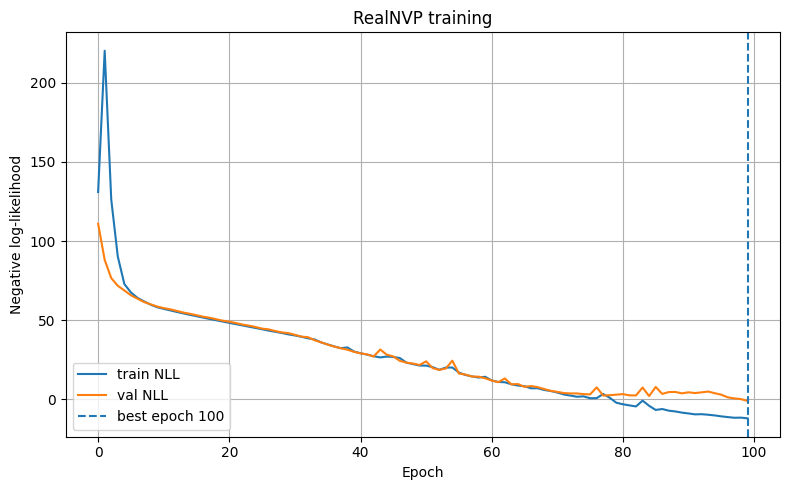

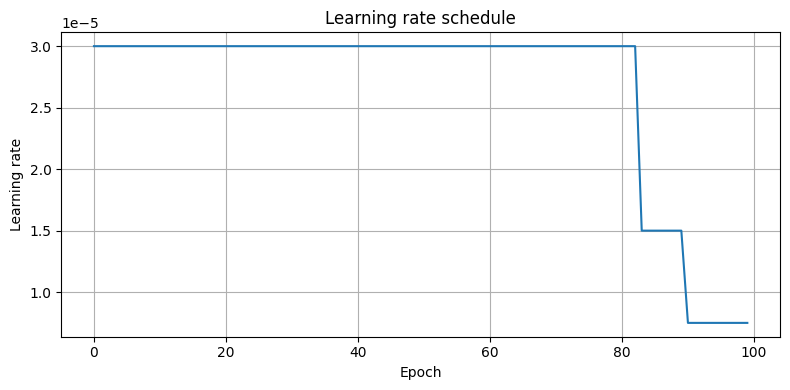

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_history, label="train NLL")
plt.plot(val_history, label="val NLL")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Negative log-likelihood")
plt.title("RealNVP training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_lr_schedule.png", dpi=200)
plt.show()

## 10. Calcolo anomaly score

In [13]:
def compute_flow_scores(model, X, batch_size=4096):
    loader = DataLoader(
        AggregateDataset(X),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()

    scores = []
    logps = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            logp = model.log_prob(X_batch)
            nll = -logp

            scores.append(nll.cpu().numpy())
            logps.append(logp.cpu().numpy())

    return np.concatenate(scores), np.concatenate(logps)


scores_train, logp_train = compute_flow_scores(flow, X_train)
scores_val, logp_val = compute_flow_scores(flow, X_val)
scores_bkg_test, logp_bkg_test = compute_flow_scores(flow, X_bkg_test)
scores_sig, logp_sig = compute_flow_scores(flow, X_sig)


def print_summary(name, scores):
    print("\n", name)
    print("mean:", float(np.mean(scores)))
    print("std:", float(np.std(scores)))
    print("median:", float(np.median(scores)))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))


print_summary("train NLL", scores_train)
print_summary("val NLL", scores_val)
print_summary("bkg_test NLL", scores_bkg_test)
print_summary("signal NLL", scores_sig)


 train NLL
mean: -12.2998628616333
std: 25.73257827758789
median: -16.591873168945312
quantiles: [ -57.07666016  -41.73727432  -36.00318108  -25.87079239  -16.59187317
   -3.90241623   22.96690598   52.40419586  250.12474489 2096.48803711]

 val NLL
mean: -0.9618275165557861
std: 1786.35888671875
median: -16.553253173828125
quantiles: [-5.62174149e+01 -4.16732941e+01 -3.57823673e+01 -2.58154736e+01
 -1.65532532e+01 -3.60709763e+00  2.39677532e+01  5.49761900e+01
  2.98483671e+02  3.56120719e+05]

 bkg_test NLL
mean: 574.8898315429688
std: 94351.671875
median: -16.637596130371094
quantiles: [-5.31758499e+01 -4.14558633e+01 -3.57038376e+01 -2.57138252e+01
 -1.66375961e+01 -3.89102554e+00  2.35052322e+01  5.68083762e+01
  3.08295520e+02  1.79907160e+07]

 signal NLL
mean: 37874.83203125
std: 4340735.0
median: 25.272171020507812
quantiles: [-5.29427261e+01 -2.83641335e+01 -1.54573402e+01  6.92159653e+00
  2.52721710e+01  5.16905975e+01  1.30710037e+02  3.06213145e+02
  6.99543529e+06  1.0

## 11. Metriche: AUC, mistag, background checks

In [14]:
def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, model_name="RealNVP"):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []
    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)

        rows.append({
            "model": model_name,
            "score": "NLL",
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual_mistag,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }


eval_main = evaluate_scores(scores_bkg_test, scores_sig, model_name="RealNVP")

print("AUC:", eval_main["auc"])
print("AUC inverted:", eval_main["auc_inverted"])
print("Best AUC:", eval_main["best_auc"])
print("Flipped:", eval_main["flipped"])

display(eval_main["eff_table"])


def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros_like(a), np.ones_like(b)])
    s = np.concatenate([a, b])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    return {
        "comparison": f"{name_a} vs {name_b}",
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
    }


bg_checks = pd.DataFrame([
    bg_vs_bg_auc(scores_train, scores_val, "train QCD", "val QCD"),
    bg_vs_bg_auc(scores_train, scores_bkg_test, "train QCD", "test QCD"),
    bg_vs_bg_auc(scores_val, scores_bkg_test, "val QCD", "test QCD"),
])

display(bg_checks)

AUC: 0.8890217590291452
AUC inverted: 0.11097824097085499
Best AUC: 0.8890217590291452
Flipped: False


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,RealNVP,NLL,0.889022,0.889022,0.110978,False,0.300,0.300,0.897944,-7.163118
1,RealNVP,NLL,0.889022,0.889022,0.110978,False,0.100,0.100,0.683536,11.894072
2,RealNVP,NLL,0.889022,0.889022,0.110978,False,0.050,0.050,0.523674,23.505232
3,RealNVP,NLL,0.889022,0.889022,0.110978,False,0.010,0.010,0.220153,56.808376
4,RealNVP,NLL,0.889022,0.889022,0.110978,False,0.001,0.001,0.009780,308.295532


,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.502285,0.497715,0.502285
1,train QCD vs test QCD,0.502027,0.497973,0.502027
2,val QCD vs test QCD,0.499748,0.500252,0.500252


## 12. ROC, score distributions, efficiency vs mistag

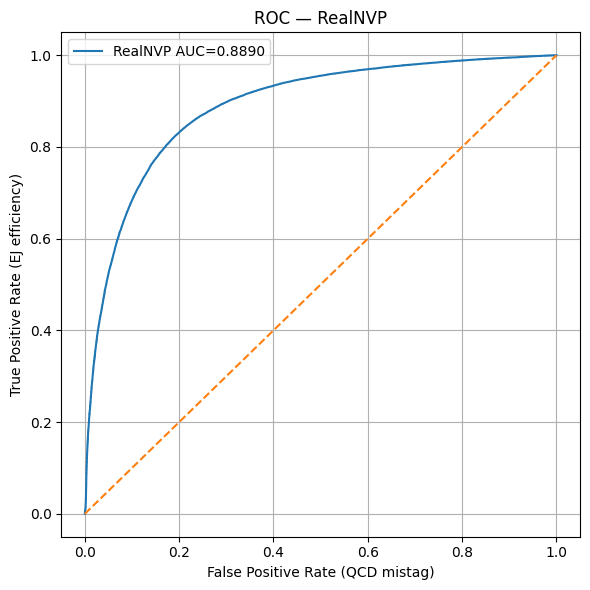

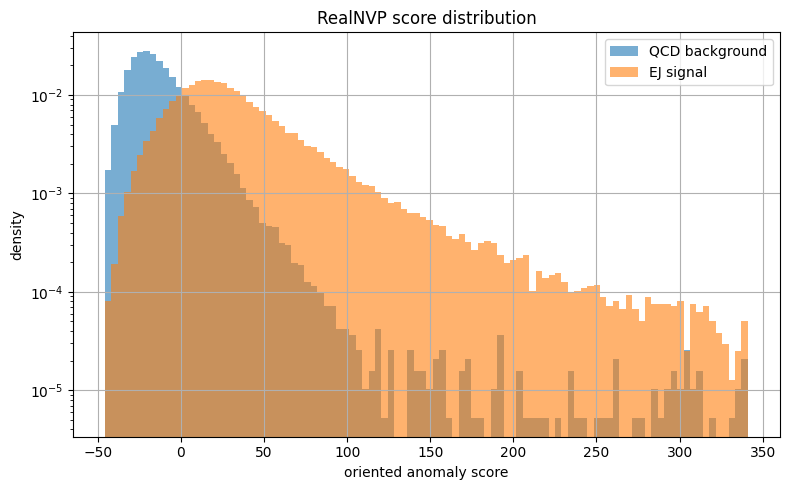

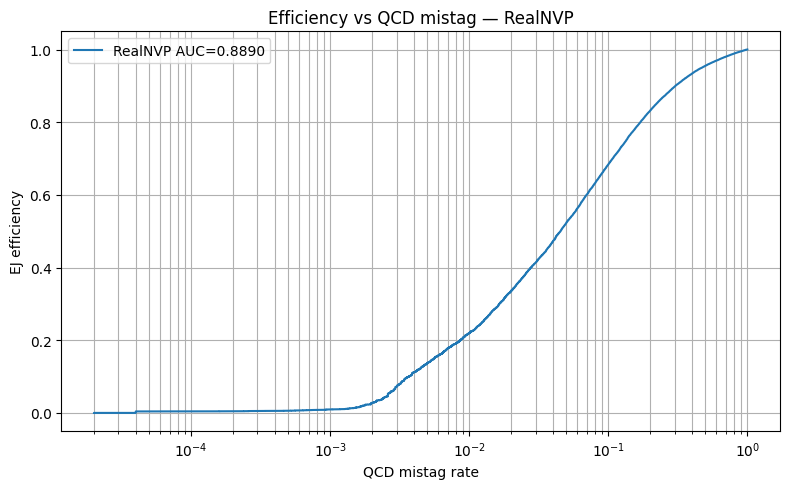

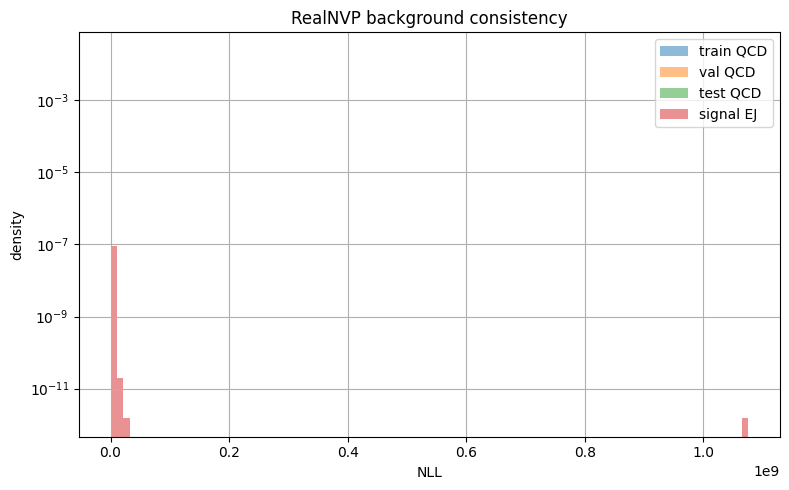

In [15]:
bg_o = eval_main["bg_oriented"]
sig_o = eval_main["sig_oriented"]

plt.figure(figsize=(6, 6))
plt.plot(eval_main["fpr"], eval_main["tpr"], label=f"RealNVP AUC={eval_main['best_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("ROC — RealNVP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_roc.png", dpi=200)
plt.show()

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)

plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ signal")
plt.yscale("log")
plt.xlabel("oriented anomaly score")
plt.ylabel("density")
plt.title("RealNVP score distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_score_distribution.png", dpi=200)
plt.show()

fpr = eval_main["fpr"]
tpr = eval_main["tpr"]
mask = fpr > 0

plt.figure(figsize=(8, 5))
plt.plot(fpr[mask], tpr[mask], label=f"RealNVP AUC={eval_main['best_auc']:.4f}")
plt.xscale("log")
plt.xlabel("QCD mistag rate")
plt.ylabel("EJ efficiency")
plt.title("Efficiency vs QCD mistag — RealNVP")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_efficiency_vs_mistag.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(scores_train, bins=100, density=True, alpha=0.5, label="train QCD")
plt.hist(scores_val, bins=100, density=True, alpha=0.5, label="val QCD")
plt.hist(scores_bkg_test, bins=100, density=True, alpha=0.5, label="test QCD")
plt.hist(scores_sig, bins=100, density=True, alpha=0.5, label="signal EJ")
plt.yscale("log")
plt.xlabel("NLL")
plt.ylabel("density")
plt.title("RealNVP background consistency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_background_consistency.png", dpi=200)
plt.show()

## 14. Salvataggio finale

In [16]:
results_summary = {
    "model": "RealNVP",
    "score": "NLL",
    "auc": float(eval_main["auc"]),
    "auc_inverted": float(eval_main["auc_inverted"]),
    "best_auc": float(eval_main["best_auc"]),
    "flipped": bool(eval_main["flipped"]),
    "input_dim": int(input_dim),
    "n_flow_layers": int(N_FLOW_LAYERS),
    "hidden_dim": int(HIDDEN_DIM),
    "scale_clip": float(SCALE_CLIP),
    "learning_rate": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "hparam_tuning_used": bool("flow_tuning_results_df" in globals()),
    "hparam_selection_score": float(BEST_FLOW_CONFIG.get("selection_score", np.nan)) if "BEST_FLOW_CONFIG" in globals() else float("nan"),
    "best_epoch": int(best_epoch),
    "best_val_nll": float(best_val),
    "clip_value": float(CLIP_VALUE),
}

for _, row in bg_checks.iterrows():
    key = row["comparison"].replace(" ", "_").replace("vs", "VS")
    results_summary[f"{key}_best_auc"] = float(row["best_auc"])

with open(OUTPUT_DIR / "realnvp_config.json", "w") as f:
    json.dump(
        {
            **results_summary,
            "aggregate_feature_names": aggregate_feature_names,
            "processed_path": str(PROCESSED_PATH),
            "scaler": scaler.state_dict(),
        },
        f,
        indent=2,
    )

eval_main["eff_table"].to_csv(OUTPUT_DIR / "realnvp_results.csv", index=False)
bg_checks.to_csv(OUTPUT_DIR / "realnvp_background_checks.csv", index=False)

torch.save(
    {
        "model_state_dict": flow.state_dict(),
        "config": results_summary,
        "aggregate_feature_names": aggregate_feature_names,
        "scaler": scaler.state_dict(),
        "train_history": train_history,
        "val_history": val_history,
    },
    OUTPUT_DIR / "realnvp_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "realnvp_scores.npz",
    scores_train=scores_train,
    scores_val=scores_val,
    scores_bkg_test=scores_bkg_test,
    scores_sig=scores_sig,
    logp_train=logp_train,
    logp_val=logp_val,
    logp_bkg_test=logp_bkg_test,
    logp_sig=logp_sig,
    bg_oriented=eval_main["bg_oriented"],
    sig_oriented=eval_main["sig_oriented"],
    fpr=eval_main["fpr"],
    tpr=eval_main["tpr"],
    thresholds=eval_main["thresholds"],
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    auc=np.array(eval_main["auc"], dtype=np.float32),
    auc_inverted=np.array(eval_main["auc_inverted"], dtype=np.float32),
    best_auc=np.array(eval_main["best_auc"], dtype=np.float32),
)

print("Saved:")
print(OUTPUT_DIR / "realnvp_model.pt")
print(OUTPUT_DIR / "realnvp_scores.npz")
print(OUTPUT_DIR / "realnvp_results.csv")
print(OUTPUT_DIR / "realnvp_background_checks.csv")
print(OUTPUT_DIR / "realnvp_config.json")
print("plots:", PLOTS_DIR)

Saved:
..\outputs\normalizing_flow\realnvp_model.pt
..\outputs\normalizing_flow\realnvp_scores.npz
..\outputs\normalizing_flow\realnvp_results.csv
..\outputs\normalizing_flow\realnvp_background_checks.csv
..\outputs\normalizing_flow\realnvp_config.json
plots: ..\outputs\normalizing_flow\plots
